# TUGAS 6 — Morfologi

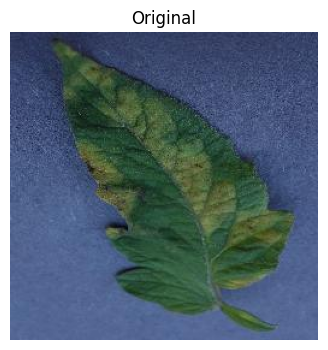

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('./assets/tomato-leafmold.JPG')
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

plt.figure(figsize=(4, 4))
plt.imshow(rgb)
plt.title('Original')
plt.axis('off')
plt.show()

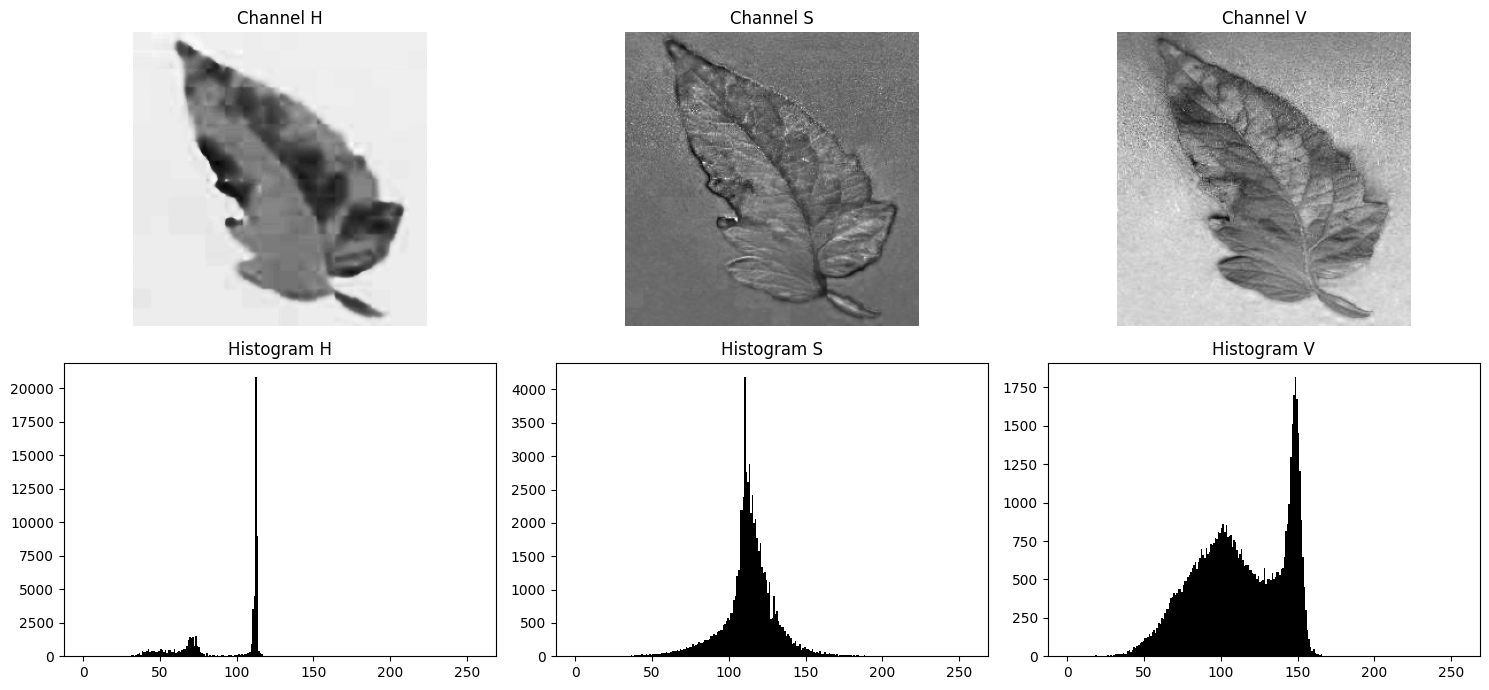

In [ ]:
# Visualisasi histogram dan masing masing channel
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for i, (ch, name) in enumerate(zip([h, s, v], ['H', 'S', 'V'])):
    axes[0, i].imshow(ch, cmap='gray')
    axes[0, i].set_title(f'Channel {name}')
    axes[0, i].axis('off')

    axes[1, i].hist(ch.ravel(), bins=256, range=[0, 256], color='black')
    axes[1, i].set_title(f'Histogram {name}')

plt.tight_layout()
plt.savefig('./assets/histogram_hue.png')
plt.show()

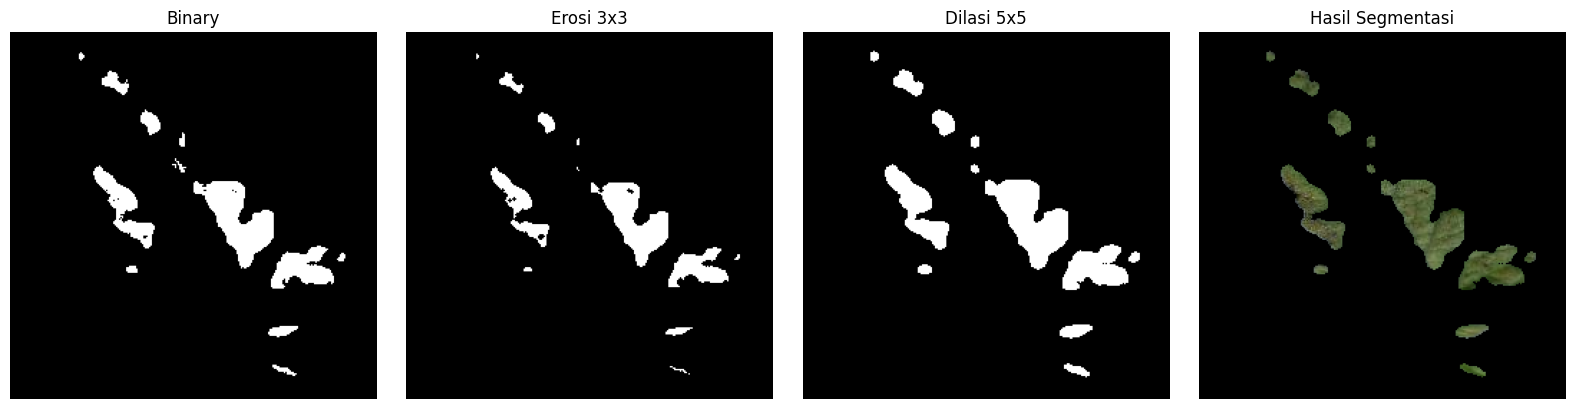

In [ ]:
# Tresholding pada ketiga channel
binary = cv2.inRange(hsv, np.array([10, 50, 50]), np.array([45, 255, 255]))

# Morfologi
k_erosi = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
k_dilasi = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
erosi = cv2.erode(binary, k_erosi)
dilasi = cv2.dilate(erosi, k_dilasi)
hasil = cv2.bitwise_and(rgb, rgb, mask=dilasi)

# Visualisasi pipeline
titles = ['Binary', 'Erosi 3x3', 'Dilasi 5x5', 'Hasil Segmentasi']
imgs = [binary, erosi, dilasi, hasil]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, (im, t) in enumerate(zip(imgs, titles)):
    axes[i].imshow(im, cmap='gray' if i < 3 else None)
    axes[i].set_title(t)
    axes[i].axis('off')
plt.tight_layout()
plt.savefig('./assets/pipeline_hue.png')
plt.show()